In [12]:
# Import
import matplotlib.pyplot as plt
import numpy as np
from math import dist
from scipy.optimize import minimize, brute
%matplotlib widget

# Les constantes
THETA = np.linspace(0, 2 * np.pi, 100)

# Les variables length et rayon du cylindre
length = 118   
radius = 48.5  

# Les variable L, l, et décalage pour l'ellipse
L = 6
l = 3
décalage = 2

# Les variables du point de vue O et du plan de projection
X0 = np.array([56, 0, 97]) # centre du plan de projection
n = np.array([1, 0, 2]) # vecteur normal au plan
coef_focale = 21
O = X0 + coef_focale*n # point de vue

# faire une Gridsearch avec :
# X[0] = np.linspace(0, 100, 10)
# X[2] = np.linspace(length/2, length, 10)
# n[1] = np.linspace(0, 10, 10)
# coef_focale = np.linspace(0, 10, 10)
# et une mesure de performance adequate
# meilleurs params :  [42.23144507 68.26429752  3.66957402  4.23350573]
# [ 5.589e+01  9.781e+01  1.936e+00  2.133e+01]

In [13]:
# Préparation :
# Récupération de l'image
img = plt.imread(r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\97_118_5.png")
plt.imshow(img)
A = np.array([31, 247])
B = np.array([187, 369])
C =  np.array([195,214])
plt.scatter(np.array([A, B, C])[:, 0], np.array([A, B, C])[:, 1], s=10, c= 'blue')


In [14]:
# Modélisation :
# Modélisation du cylindre et de la porosité

# Les cercles de base du cylindre
x_circle1 = radius * np.cos(THETA)
y_circle1 = radius * np.sin(THETA)   
z_circle1 = np.full_like(THETA, length/2)  # Le cercle est à z = length/2
x_circle2 = radius * np.cos(THETA)
y_circle2 = radius * np.sin(THETA)
z_circle2 = np.full_like(THETA, -length/2)  # Le cercle est à z = -length/2 

# L'ellipse de porosité
y_ellipse = l * np.sin(THETA)   
z_ellipse = décalage + L * np.cos(THETA)
x_ellipse = np.full_like(y_ellipse, -radius)

# Modélisation du point de vue et du plan de projection
# Le point de vue O est déjà défini dans la partie variables

# Le plan de projection est défini par le point X0 et le vecteur normal n
# Création d'une grille de points (x, y)
xp = np.linspace(-2*radius, 2*radius, 20)
yp = np.linspace(-2*radius, 2*radius, 20)
Xp, Yp = np.meshgrid(xp, yp) # meshgrid est nécessaire pour plot_surface

# Résolution de l'équation du plan pour z : n_x*(x - X0_x) + n_y*(y - X0_y) + n_z*(z - X0_z) = 0
# => z = X0_z - (n_x*(x - X0_x) + n_y*(y - X0_y)) / n_z
Zp = X0[2] - (n[0]*(Xp - X0[0]) + n[1]*(Yp - X0[1])) / n[2]



In [15]:
# Calcul :
# Calcul des projections du cylindre et de l'ellipse sur le plan
# Fonction pour projeter un point P sur le plan défini par le point X0 et le vecteur normal A par rapport à un point de vue O
def projeter_sur_plan(P, n, X0, O):
    '''Projette un point P observé depuis le point d'observation O sur un plan de vision défini par son vecteur normal n et un point X0
    args :
        P (np.array(3)) : les coordonnées du point observé
        n (np.array(3)) : les coordonnées un vecteur normal au plan de vision
        X0 (np.array(3)) : les coordonnées un point appartenant au plan de vision
        O (np.array(3)) : les coordonnées du point d'observation
    return :
        np.array(3) : les coordonnées de la projection du point P sur le plan de vision par homothétie de centre O
        '''
    # Vecteur de P à O
    OP = O - P
    # Intersection de OP avec le plan
    t = np.dot(n, X0 - P) / np.dot(n, OP)
    return P + t * OP

#Projection des deux cercles du cylindre et de l'ellipse sur le plan de projection
cyl_proj1 = np.array([projeter_sur_plan(np.array([x_circle1[i], y_circle1[i], z_circle1[i]]), n, X0, O) for i in range(len(THETA))])
cyl_proj2 = np.array([projeter_sur_plan(np.array([x_circle2[i], y_circle2[i], z_circle2[i]]), n, X0, O) for i in range(len(THETA))])
ell_proj = np.array([projeter_sur_plan(np.array([x_ellipse[i], y_ellipse[i], z_ellipse[i]]), n, X0, O) for i in range(len(THETA))])

Text(0.5, 0.92, 'Projection du cylindre et de sa porosité sur le plan de vision')

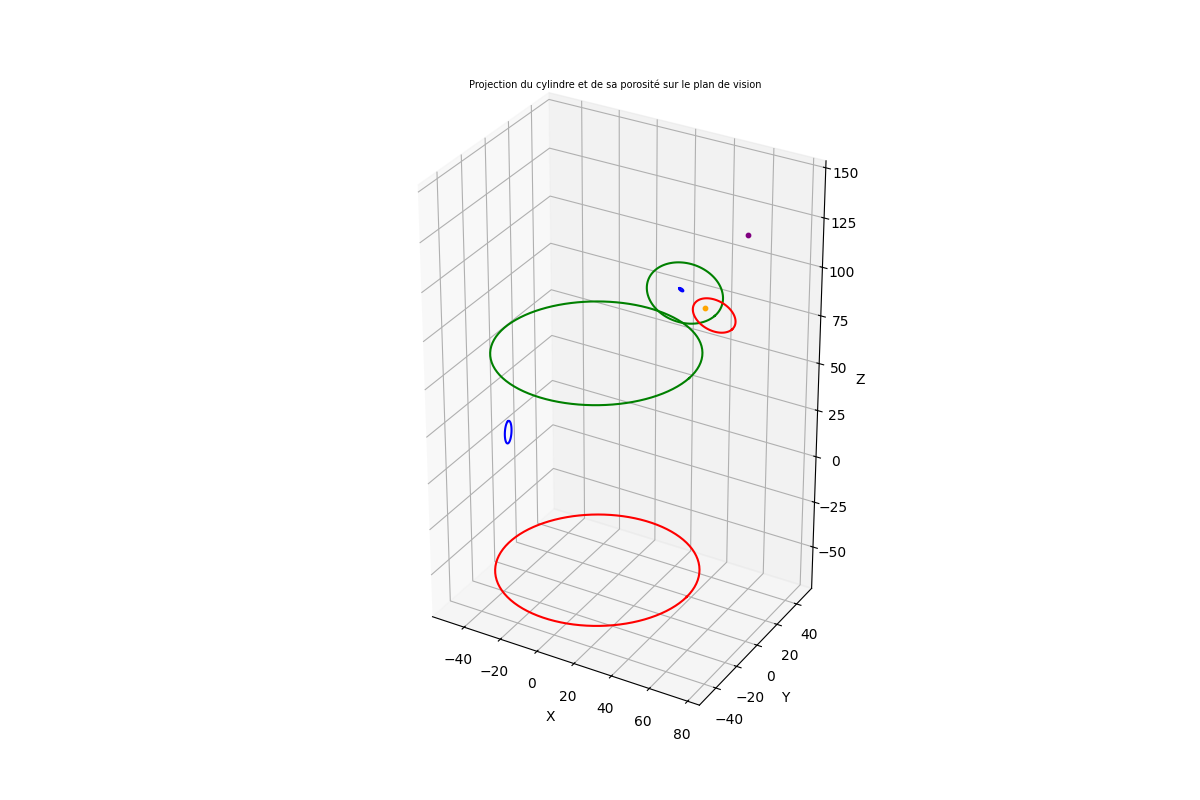

In [16]:
# Visualisation :
# Visualisation 3D

# Définition de la figure et des axes 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracé des cercles de base du cylindre et de l'ellipse de porosité
ax.plot(x_circle1, y_circle1, z_circle1, color='green', label='Cercle1 de base du cylindre')
ax.plot(x_circle2, y_circle2, z_circle2, color='red', label='Cercle2 de base du cylindre')
ax.plot(x_ellipse, y_ellipse, z_ellipse, color='blue', label='Ellipse de porosité')

# Tracé du point X0
ax.scatter(X0[0], X0[1], X0[2], color='orange', s=10, label='Point X0 (centre du plan de projection)')

# Tracé du plan
#ax.plot_surface(Xp, Yp, Zp, alpha=0.5, color='lightblue', label='Plan')

# Tracé du point de vue O
ax.scatter(O[0], O[1], O[2], color='purple', s=10, label='Point de vue O')

# Tracé de la projection du cylindre et de l'ellipse sur le plan
ax.plot(cyl_proj1[:, 0], cyl_proj1[:, 1], cyl_proj1[:, 2], color='green', label='Projection du cercle1 sur le plan')
ax.plot(cyl_proj2[:, 0], cyl_proj2[:, 1], cyl_proj2[:, 2], color='red', label='Projection du cercle2 sur le plan')
ax.plot(ell_proj[:, 0], ell_proj[:, 1], ell_proj[:, 2], color='blue', label='Projection de l\'ellipse sur le plan')

# Configuration du graphique
ax.set_aspect('equal')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Projection du cylindre et de sa porosité sur le plan de vision', fontsize=7)


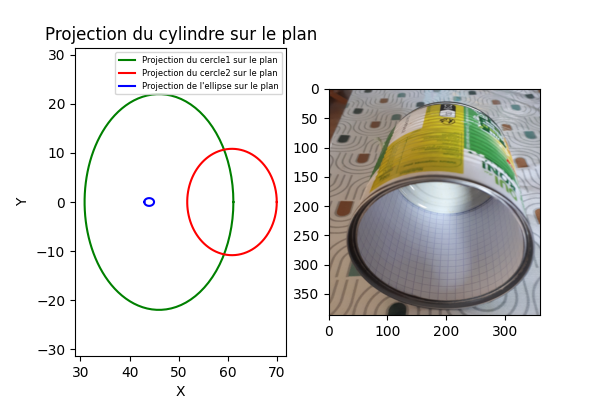

In [17]:
# Comparaison de l'image réelle et de la projection du cylindre et de l'ellipse sur le plan
fif, ax = plt.subplots(1, 2, figsize=(6, 4))

# Tracé de la projection du cylindre et de l'ellipse sur le plan
ax[0].plot(cyl_proj1[:, 0], cyl_proj1[:, 1], color='green', label='Projection du cercle1 sur le plan')
ax[0].plot(cyl_proj2[:, 0], cyl_proj2[:, 1], color='red', label='Projection du cercle2 sur le plan')
ax[0].plot(ell_proj[:, 0], ell_proj[:, 1], color='blue', label='Projection de l\'ellipse sur le plan')

ax[0].axis('equal')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].set_title('Projection du cylindre sur le plan')
ax[0].legend(loc='upper right', fontsize='6')
#ax[0].tight_layout()
ax[1].imshow(img)


In [19]:
# Résolution :
# Définition de la métrique
resol_img = plt.imread(r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\résolution.jpg")
plt.imshow(resol_img)
# metric = (delta(a/b)^2 + delta(b/c)^2 + delta(c/a)^2)
a = dist(A, B)
b = dist(B, C)
c = dist(C, A)
Ap = cyl_proj1[np.argmax(cyl_proj1[:,1])][:2]
Bp = cyl_proj1[np.argmin(cyl_proj1[:,0])][:2]
Cp = cyl_proj2[np.argmin(cyl_proj1[:,0])][:2]
ap = dist(Ap, Bp)
bp = dist(Bp, Cp)
cp = dist(Cp, Ap)

# metric = np.square(a/b - ap/bp) + np.square(b/c - bp/cp) + np.square(c/a - cp/ap)
# ap => Ap => cyl_proj1 => projeter_sur_plan(np.array([x_circle1[i], y_circle1[i], z_circle1[i]]), n, X0, O) => O => X0 et coef_focale

def metric(params):
    X00, X02, n2, coef_focale = params  # Décomposer le tableau en paramètres
    X0 = np.array([X00, 0, X02])
    n = np.array([1, 0, n2])
    O = X0 + coef_focale*n

    cyl_proj1 = np.array([projeter_sur_plan(np.array([x_circle1[i], y_circle1[i], z_circle1[i]]), n, X0, O) for i in range(len(THETA))])
    cyl_proj2 = np.array([projeter_sur_plan(np.array([x_circle2[i], y_circle2[i], z_circle2[i]]), n, X0, O) for i in range(len(THETA))])
    ell_proj = np.array([projeter_sur_plan(np.array([x_ellipse[i], y_ellipse[i], z_ellipse[i]]), n, X0, O) for i in range(len(THETA))])

    Ap = cyl_proj1[np.argmax(cyl_proj1[:,1])][:2]
    Bp = cyl_proj1[np.argmin(cyl_proj1[:,0])][:2]
    Cp = cyl_proj2[np.argmin(cyl_proj1[:,0])][:2]
    ap = dist(Ap, Bp)
    bp = dist(Bp, Cp)
    cp = dist(Cp, Ap)

    if np.any([ap == 0, bp == 0, cp == 0]):
        return 1000

    
    
    return np.square(a/b - ap/bp) + np.square(b/c - bp/cp) + np.square(c/a - cp/ap)

# Recherche de la solution par grille
# params
# X0[0] = np.linspace(0, 100, 10)
# X0[2] = np.linspace(length/2, length, 10)
# n[2] = np.linspace(0, 10, 10)
# coef_focale = np.linspace(0, 10, 10)

ranges = (
    np.linspace(0, 100, 2),          # X00
    np.linspace(length / 2, length, 2),  # X02
    np.linspace(0, 10, 2),           # n2
    np.linspace(0, 10, 2)            # coef_focale
)

result = minimize(metric, [42.23144507, 100.26429752,  0.2,  10.23350573])
print("Meilleurs paramètres :", result.x)
print("Valeur minimale de la métrique :", result.fun)

Meilleurs paramètres : [55.88785481 97.80637222  1.93580318 21.33137155]
Valeur minimale de la métrique : 2.922382817464594e-10


In [18]:
result = minimize(metric, [42.23144507, 100.26429752,  0.2,  10.23350573])
print("Meilleurs paramètres :", result.x)
print("Valeur minimale de la métrique :", result.fun)

Meilleurs paramètres : [55.88785481 97.80637222  1.93580318 21.33137155]
Valeur minimale de la métrique : 2.922382817464594e-10
